In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# File path to the Parquet file
file_path = '/content/drive/My Drive/AIP/combined_data.parquet'

# Read the Parquet file
data = pd.read_parquet(file_path)

# Display the first few rows
print(data.head())

      videoid                                         contentUrl     duration  \
0    21179416  https://ak.picdn.net/shutterstock/videos/21179...  PT00H00M11S   
1     5629184  https://ak.picdn.net/shutterstock/videos/56291...  PT00H00M29S   
2  1063125190  https://ak.picdn.net/shutterstock/videos/10631...  PT00H00M07S   
3  1039695998  https://ak.picdn.net/shutterstock/videos/10396...  PT00H00M08S   
4     9607838  https://ak.picdn.net/shutterstock/videos/96078...  PT00H00M32S   

        page_dir                                               name  
0  006001_006050                          Aerial shot winter forest  
1  071501_071550  Senior couple looking through binoculars on sa...  
2  133701_133750  A beautiful cookie with oranges lies on a gree...  
3  011901_011950  Japanese highrise office skyscrapers tokyo square  
4  121551_121600  Zrenjanin,serbia march 21 2015: fans watching ...  


In [3]:
# Path to save the CSV file
csv_output_path = '/content/drive/My Drive/AIP/combined_data.csv'

# Convert and save
data.to_csv(csv_output_path, index=False)
print(f"Parquet file successfully converted to CSV and saved at {csv_output_path}")

Parquet file successfully converted to CSV and saved at /content/drive/My Drive/AIP/combined_data.csv


page_dir
000001_000050    4839
061101_061150    4704
032001_032050    4660
144051_144100    4655
071601_071650    4652
                 ... 
098951_099000     858
091051_091100     818
091501_091550     809
169951_170000      75
131751_131800      53
Name: count, Length: 3590, dtype: int64


<Axes: title={'center': 'Category Distribution'}, xlabel='page_dir'>

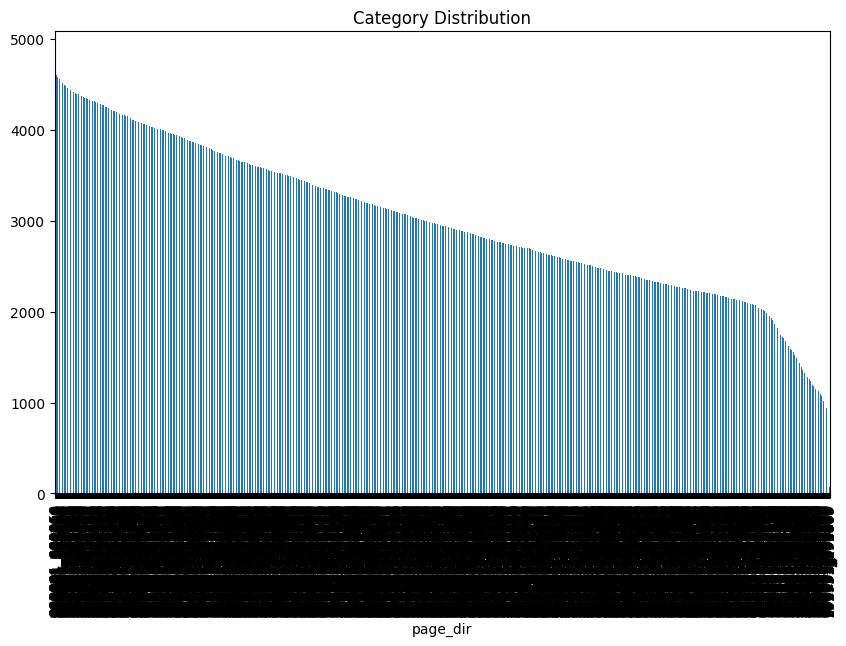

In [4]:
# Check distribution of categories
category_counts = data['page_dir'].value_counts()
print(category_counts)

# Visualize the distribution
category_counts.plot(kind='bar', figsize=(10, 6), title='Category Distribution')

Performing Stratified **sampling**

In [5]:
import pandas as pd

# Load the dataset
csv_file_path = '/content/drive/My Drive/AIP/combined_data.csv'
data = pd.read_csv(csv_file_path)

# Define sample size
sample_size = 20000

# Perform stratified sampling
stratified_sample = data.groupby('page_dir', group_keys=False).apply(
    lambda x: x.sample(frac=sample_size / len(data), random_state=42)
)

# Save the stratified sample
stratified_sample.to_csv('/content/drive/My Drive/AIP/stratified_sample_data.csv', index=False)
print("Stratified sample saved successfully.")

<ipython-input-5-6918f62140d5>:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = data.groupby('page_dir', group_keys=False).apply(


Stratified sample saved successfully.


In [6]:
print(stratified_sample.isnull().sum())

videoid       0
contentUrl    0
duration      0
page_dir      0
name          0
dtype: int64


In [7]:
print(f"Duplicate rows: {stratified_sample.duplicated().sum()}")

Duplicate rows: 0


In [8]:
!pip install isodate

In [9]:
import isodate

# Convert 'duration' to seconds
stratified_sample['duration_seconds'] = stratified_sample['duration'].apply(
    lambda x: isodate.parse_duration(x).total_seconds()
)

# Verify the conversion
print(stratified_sample[['duration', 'duration_seconds']].head())

            duration  duration_seconds
7047485  PT00H00M07S               7.0
5552607  PT00H00M16S              16.0
9048114  PT00H00M11S              11.0
4220415  PT00H00M07S               7.0
3332764  PT00H00M09S               9.0


In [10]:
# Filter videos with duration between 5 seconds and 10 minutes
stratified_sample = stratified_sample[
    (stratified_sample['duration_seconds'] >= 5) &
    (stratified_sample['duration_seconds'] <= 600)
]

# Check the number of rows after filtering
print(f"Remaining rows after filtering by duration: {len(stratified_sample)}")

Remaining rows after filtering by duration: 19905


In [16]:
print(stratified_sample.columns)

Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name',
       'duration_seconds'],
      dtype='object')


In [17]:
# Drop the redundant 'duration' column
stratified_sample = stratified_sample.drop(columns=['duration'])

# Verify the updated dataset
print(stratified_sample.columns)

# Save the updated dataset
stratified_sample.to_csv('/content/drive/My Drive/AIP/cleaned_sample.csv', index=False)

print("Updated dataset saved successfully as 'cleaned_sample.csv'.")

Index(['videoid', 'contentUrl', 'page_dir', 'name', 'duration_seconds'], dtype='object')
Updated dataset saved successfully as 'cleaned_sample.csv'.


In [18]:
import pandas as pd

# Load the cleaned sample
cleaned_sample_path = '/content/drive/My Drive/AIP/cleaned_sample.csv'
cleaned_sample = pd.read_csv(cleaned_sample_path)

# Verify the data
print(cleaned_sample.head())
print(cleaned_sample.info())


      videoid                                         contentUrl  \
0  1066698565  https://ak.picdn.net/shutterstock/videos/10666...   
1  1066695709  https://ak.picdn.net/shutterstock/videos/10666...   
2  1066686421  https://ak.picdn.net/shutterstock/videos/10666...   
3  1066701139  https://ak.picdn.net/shutterstock/videos/10667...   
4  1066681600  https://ak.picdn.net/shutterstock/videos/10666...   

        page_dir                                               name  \
0  000001_000050        Road in the forest, winter beautiful nature   
1  000001_000050  Side view asian women fat shape barefoot in ex...   
2  000001_000050  Castle of lloret de mar, spain, castell d'en p...   
3  000001_000050       Haut-mbomou prefecture map outline animation   
4  000001_000050  Asian senior woman and niece decorate house fo...   

   duration_seconds  
0               7.0  
1              16.0  
2              11.0  
3               7.0  
4               9.0  
<class 'pandas.core.frame.DataFr

In [19]:
cleaned_sample['duration_seconds'].describe()

,duration_seconds
count,19905.000000
mean,18.054157
std,11.982641
min,5.000000
25%,10.000000
50%,15.000000
75%,22.000000
max,188.000000


In [20]:
cleaned_sample['page_dir'].value_counts()

,count
page_dir,
000001_000050,9
144051_144100,9
148101_148150,9
032001_032050,9
137401_137450,9
...,...
040601_040650,2
103801_103850,2
099501_099550,2


In [21]:
# Group by 'page_dir' and count the number of rows in each group
page_dir_counts = cleaned_sample['page_dir'].value_counts()

# Display the total number of unique 'page_dir' values
print(f"Unique page_dir values: {cleaned_sample['page_dir'].nunique()}")

# Display the total number of rows in the dataset
print(f"Total rows in dataset: {len(cleaned_sample)}")

# Display the first few counts for each 'page_dir'
print(page_dir_counts.head())

Unique page_dir values: 3588
Total rows in dataset: 19905
page_dir
000001_000050    9
144051_144100    9
148101_148150    9
032001_032050    9
137401_137450    9
Name: count, dtype: int64


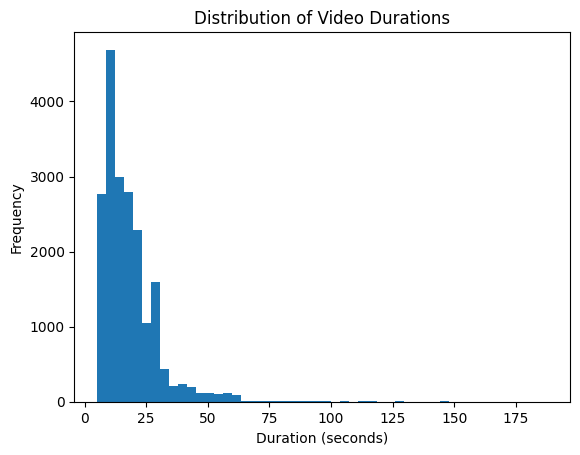

In [22]:
# Distribution of video durations
import matplotlib.pyplot as plt

plt.hist(cleaned_sample['duration_seconds'], bins=50)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Video Durations')
plt.show()

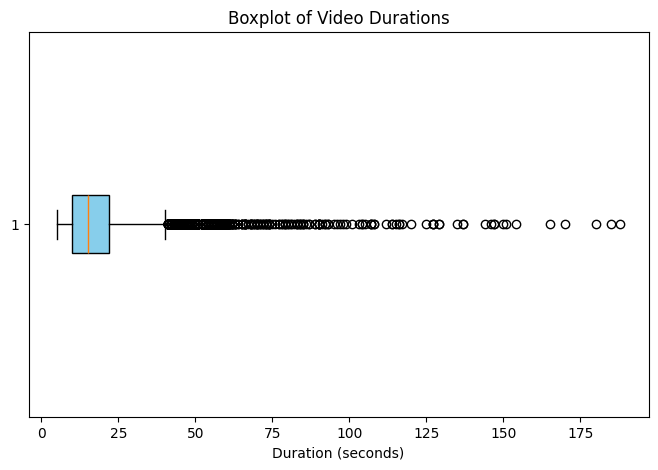

In [31]:
# Boxplot for video durations
plt.figure(figsize=(8, 5))
plt.boxplot(cleaned_sample['duration_seconds'], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.xlabel('Duration (seconds)')
plt.title('Boxplot of Video Durations')
plt.show()

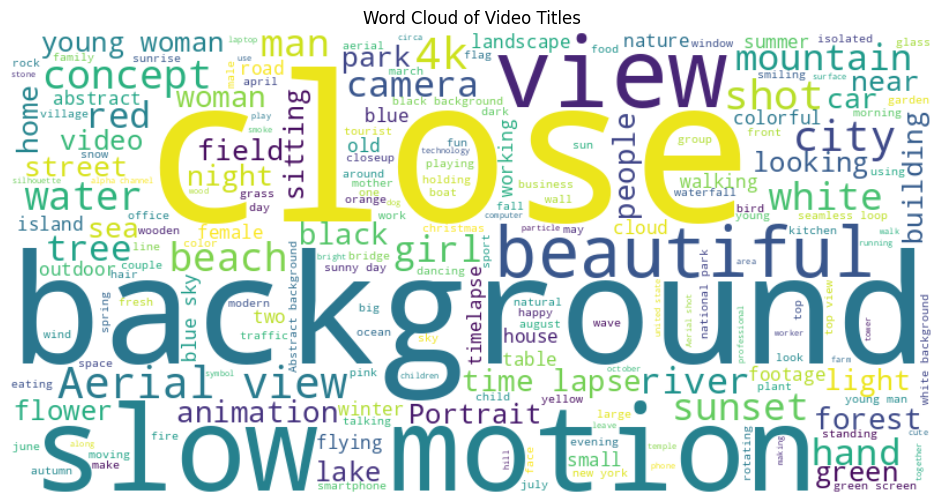

In [27]:
from wordcloud import WordCloud

# Combine all video titles into a single text
title_text = ' '.join(cleaned_sample['name'].dropna().astype(str))

# Generate and plot a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(title_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Video Titles')
plt.show()

In [33]:
pip install requests

In [34]:
import os
import requests


# Randomly sample 200 rows from the  DataFrame
sample_df = cleaned_sample.sample(n=200, random_state=42)

# Function to download a video
def download_video(url, save_path):
    try:
        response = requests.get(url, stream=True, timeout=10)  # Added timeout for better handling
        response.raise_for_status()  # Raise an error for bad status codes
        with open(save_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"Video downloaded successfully: {save_path}")
    except Exception as e:
        print(f"Failed to download video from {url}: {e}")

# Create a directory to save the videos (if it doesn't exist)
output_dir = "downloaded_videos"
os.makedirs(output_dir, exist_ok=True)

# Loop through the sampled rows and download videos
for index, row in sample_df.iterrows():
    video_url = row['contentUrl']
    save_path = os.path.join(output_dir, f"video_{index}.mp4")  # Save in the output directory
    download_video(video_url, save_path)

Video downloaded successfully: downloaded_videos/video_10366.mp4
Video downloaded successfully: downloaded_videos/video_6161.mp4
Video downloaded successfully: downloaded_videos/video_12000.mp4
Video downloaded successfully: downloaded_videos/video_17222.mp4
Video downloaded successfully: downloaded_videos/video_18845.mp4
Video downloaded successfully: downloaded_videos/video_4630.mp4
Video downloaded successfully: downloaded_videos/video_10879.mp4
Video downloaded successfully: downloaded_videos/video_17366.mp4
Video downloaded successfully: downloaded_videos/video_16159.mp4
Video downloaded successfully: downloaded_videos/video_15841.mp4
Video downloaded successfully: downloaded_videos/video_19544.mp4
Video downloaded successfully: downloaded_videos/video_12553.mp4
Video downloaded successfully: downloaded_videos/video_2771.mp4
Video downloaded successfully: downloaded_videos/video_18691.mp4
Video downloaded successfully: downloaded_videos/video_13708.mp4
Video downloaded successfull